<a href="https://colab.research.google.com/github/Marcelo-Zambiazzo/Challenge-Allura-Store/blob/main/Challenge_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
clientes = pd.read_json('/content/TelecomX_Data.json')

In [5]:
clientes.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
clientes.shape

(7267, 6)

In [7]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [8]:
clientes.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [9]:
clientes['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [10]:
clientes['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


In [11]:
clientes = pd.json_normalize(clientes.to_dict('records'), sep='_')
clientes.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [12]:
clientes.shape

(7267, 21)

In [13]:
clientes.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [14]:
cols_to_clean = ['account_Charges_Monthly','account_Charges_Total']
clientes[cols_to_clean] = (
    clientes[cols_to_clean].astype(str) # Convertir a string para usar .str accessor
    .apply(lambda x: x.str.strip()) # Quitar espacios de cada serie
    .replace("", None)               # Reemplazar strings vacíos por None
)

clientes[cols_to_clean] = clientes[cols_to_clean].apply(pd.to_numeric, errors='coerce')
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [15]:
# Clientes que se dieron de baja
clientes_churn_yes = clientes[clientes['Churn'] == 'Yes']
clientes_churn_yes.head()



,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40
18,0022-TCJCI,Yes,Male,1,No,No,45,Yes,No,DSL,...,No,Yes,No,No,Yes,One year,No,Credit card (automatic),62.7,2791.50
19,0023-HGHWL,Yes,Male,1,No,No,1,No,No phone service,DSL,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,25.1,25.10


In [16]:
clientes_churn_yes.shape

(1869, 21)

In [17]:
clientes_churn_yes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1869 entries, 2 to 7263
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 1869 non-null   object 
 1   Churn                      1869 non-null   object 
 2   customer_gender            1869 non-null   object 
 3   customer_SeniorCitizen     1869 non-null   int64  
 4   customer_Partner           1869 non-null   object 
 5   customer_Dependents        1869 non-null   object 
 6   customer_tenure            1869 non-null   int64  
 7   phone_PhoneService         1869 non-null   object 
 8   phone_MultipleLines        1869 non-null   object 
 9   internet_InternetService   1869 non-null   object 
 10  internet_OnlineSecurity    1869 non-null   object 
 11  internet_OnlineBackup      1869 non-null   object 
 12  internet_DeviceProtection  1869 non-null   object 
 13  internet_TechSupport       1869 non-null   object 
 1

In [18]:
# Resumen estadístico
print(clientes_churn_yes['customer_tenure'].describe())

count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: customer_tenure, dtype: float64


In [19]:
# Clientes que NO se dieron de baja
clientes_churn_no = clientes[clientes['Churn'] == 'No']
clientes_churn_no.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
5,0013-MHZWF,No,Female,0,No,Yes,9,Yes,No,DSL,...,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),69.40,571.45
6,0013-SMEOE,No,Female,1,Yes,No,71,Yes,No,Fiber optic,...,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),109.70,7904.25
7,0014-BMAQU,No,Male,0,Yes,No,63,Yes,Yes,Fiber optic,...,No,No,Yes,No,No,Two year,Yes,Credit card (automatic),84.65,5377.80


In [20]:
clientes_churn_no.shape

(5174, 21)

In [21]:
clientes_churn_no.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5174 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 5174 non-null   object 
 1   Churn                      5174 non-null   object 
 2   customer_gender            5174 non-null   object 
 3   customer_SeniorCitizen     5174 non-null   int64  
 4   customer_Partner           5174 non-null   object 
 5   customer_Dependents        5174 non-null   object 
 6   customer_tenure            5174 non-null   int64  
 7   phone_PhoneService         5174 non-null   object 
 8   phone_MultipleLines        5174 non-null   object 
 9   internet_InternetService   5174 non-null   object 
 10  internet_OnlineSecurity    5174 non-null   object 
 11  internet_OnlineBackup      5174 non-null   object 
 12  internet_DeviceProtection  5174 non-null   object 
 13  internet_TechSupport       5174 non-null   object 
 1

In [22]:
# Resumen estadístico
print(clientes_churn_no['customer_tenure'].describe())


count    5174.000000
mean       37.569965
std        24.113777
min         0.000000
25%        15.000000
50%        38.000000
75%        61.000000
max        72.000000
Name: customer_tenure, dtype: float64


In [23]:
clientes_churn_yes['account_Contract'].value_counts()

,count
account_Contract,
Month-to-month,1655
One year,166
Two year,48


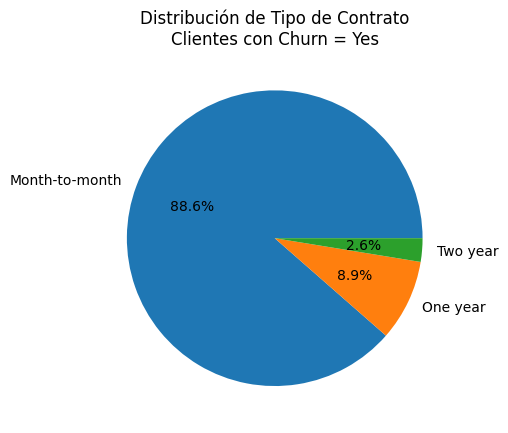

In [24]:
plt.figure()

contract_counts = clientes_churn_yes['account_Contract'].value_counts()

plt.pie(contract_counts,
        labels=contract_counts.index,
        autopct='%1.1f%%')

plt.title('Distribución de Tipo de Contrato\nClientes con Churn = Yes')

plt.show()

In [25]:
clientes_churn_no['account_Contract'].value_counts()

,count
account_Contract,
Month-to-month,2220
Two year,1647
One year,1307


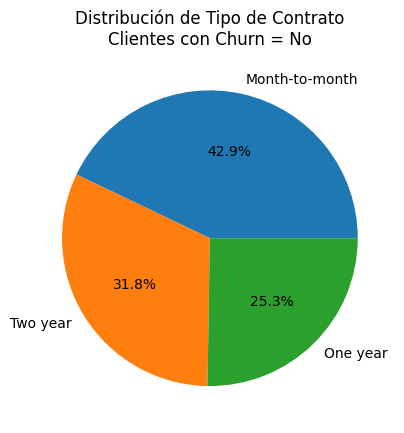

In [26]:
plt.figure()

contract_counts = clientes_churn_no['account_Contract'].value_counts()

plt.pie(contract_counts,
        labels=contract_counts.index,
        autopct='%1.1f%%')

plt.title('Distribución de Tipo de Contrato\nClientes con Churn = No')

plt.show()

In [27]:
clientes_churn_yes['internet_InternetService'].value_counts()

,count
internet_InternetService,
Fiber optic,1297
DSL,459
No,113


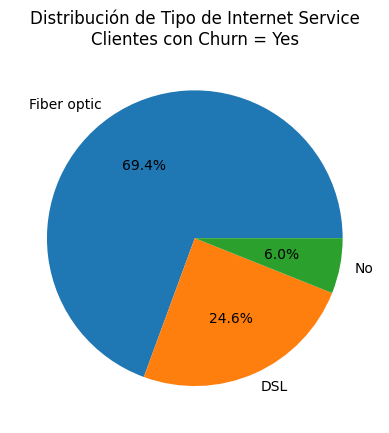

In [28]:
plt.figure()

contract_counts = clientes_churn_yes['internet_InternetService'].value_counts()

plt.pie(contract_counts,
        labels=contract_counts.index,
        autopct='%1.1f%%')

plt.title('Distribución de Tipo de Internet Service\nClientes con Churn = Yes')

plt.show()

In [29]:
clientes_churn_no['internet_InternetService'].value_counts()

,count
internet_InternetService,
DSL,1962
Fiber optic,1799
No,1413


In [30]:
clientes_churn_yes['internet_StreamingTV'].value_counts()

,count
internet_StreamingTV,
No,942
Yes,814
No internet service,113


In [31]:
clientes_churn_no['internet_StreamingTV'].value_counts()

,count
internet_StreamingTV,
Yes,1893
No,1868
No internet service,1413


In [32]:
clientes_churn_yes['internet_StreamingMovies'].value_counts()

,count
internet_StreamingMovies,
No,938
Yes,818
No internet service,113


In [33]:
clientes_churn_no['internet_StreamingMovies'].value_counts()

,count
internet_StreamingMovies,
Yes,1914
No,1847
No internet service,1413


In [34]:
clientes_churn_yes['account_PaymentMethod'].value_counts()

,count
account_PaymentMethod,
Electronic check,1071
Mailed check,308
Bank transfer (automatic),258
Credit card (automatic),232


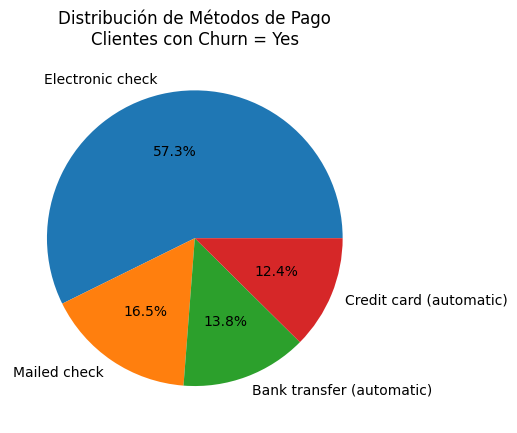

In [35]:
plt.figure()

payment_counts = clientes_churn_yes['account_PaymentMethod'].value_counts()

plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%')

plt.title('Distribución de Métodos de Pago\nClientes con Churn = Yes')

plt.show()

In [36]:
clientes_churn_no['account_PaymentMethod'].value_counts()

,count
account_PaymentMethod,
Mailed check,1304
Electronic check,1294
Credit card (automatic),1290
Bank transfer (automatic),1286


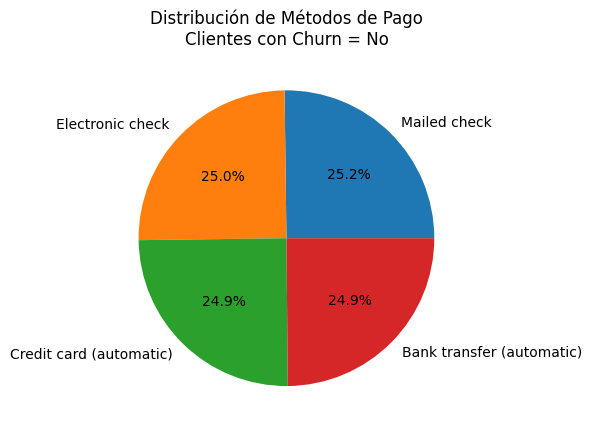

In [37]:
plt.figure()

payment_counts = clientes_churn_no['account_PaymentMethod'].value_counts()

plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%')

plt.title('Distribución de Métodos de Pago\nClientes con Churn = No')

plt.show()

In [38]:
clientes_churn_yes['customer_SeniorCitizen'].value_counts()

,count
customer_SeniorCitizen,
0,1393
1,476


In [39]:
clientes_churn_no['customer_SeniorCitizen'].value_counts()

,count
customer_SeniorCitizen,
0,4508
1,666


In [40]:
clientes_churn_yes['internet_TechSupport'].value_counts()

,count
internet_TechSupport,
No,1446
Yes,310
No internet service,113


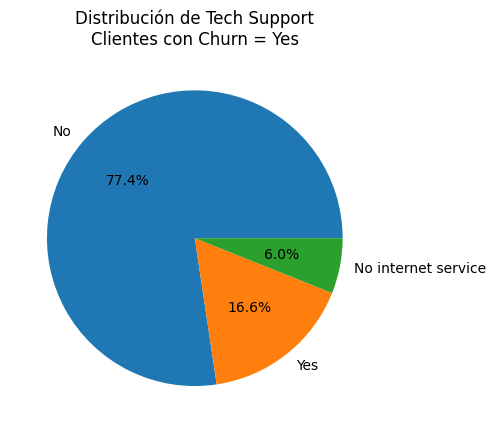

In [41]:
plt.figure()

payment_counts = clientes_churn_yes['internet_TechSupport'].value_counts()

plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%')

plt.title('Distribución de Tech Support\nClientes con Churn = Yes')

plt.show()

In [42]:
clientes_churn_no['internet_TechSupport'].value_counts()

,count
internet_TechSupport,
No,2027
Yes,1734
No internet service,1413


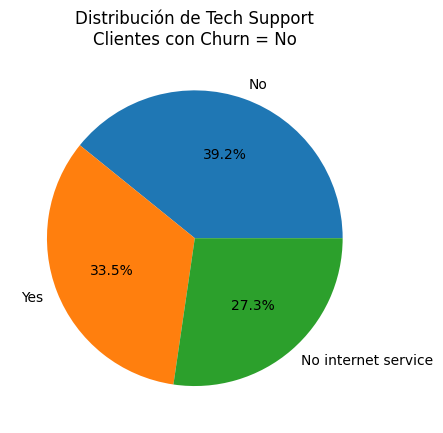

In [43]:
plt.figure()

payment_counts = clientes_churn_no['internet_TechSupport'].value_counts()

plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%')

plt.title('Distribución de Tech Support\nClientes con Churn = No')

plt.show()

In [44]:
print(clientes_churn_yes['account_Charges_Monthly'].describe())

count    1869.000000
mean       74.441332
std        24.666053
min        18.850000
25%        56.150000
50%        79.650000
75%        94.200000
max       118.350000
Name: account_Charges_Monthly, dtype: float64


In [45]:
print(clientes_churn_no['account_Charges_Monthly'].describe())

count    5174.000000
mean       61.265124
std        31.092648
min        18.250000
25%        25.100000
50%        64.425000
75%        88.400000
max       118.750000
Name: account_Charges_Monthly, dtype: float64


In [46]:
print(clientes_churn_yes['customer_Partner'].value_counts())

customer_Partner
No     1200
Yes     669
Name: count, dtype: int64


In [47]:
print(clientes_churn_no['customer_Partner'].value_counts())

customer_Partner
Yes    2733
No     2441
Name: count, dtype: int64


In [48]:
print(clientes_churn_yes['account_PaperlessBilling'].value_counts())

account_PaperlessBilling
Yes    1400
No      469
Name: count, dtype: int64


In [49]:
print(clientes_churn_no['account_PaperlessBilling'].value_counts())

account_PaperlessBilling
Yes    2771
No     2403
Name: count, dtype: int64


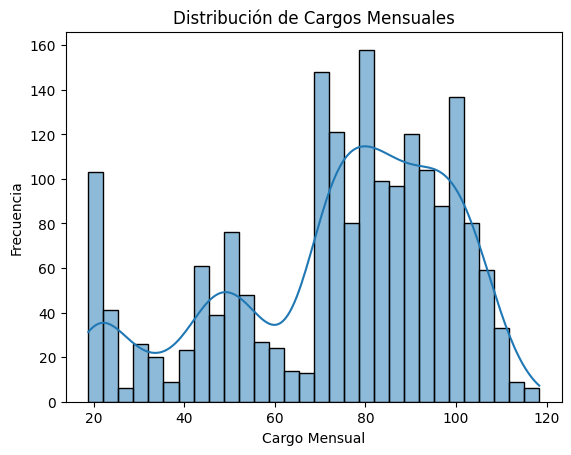

In [50]:
plt.figure()
sns.histplot(clientes_churn_yes['account_Charges_Monthly'], bins=30, kde=True)

plt.title('Distribución de Cargos Mensuales')
plt.xlabel('Cargo Mensual')
plt.ylabel('Frecuencia')

plt.show()

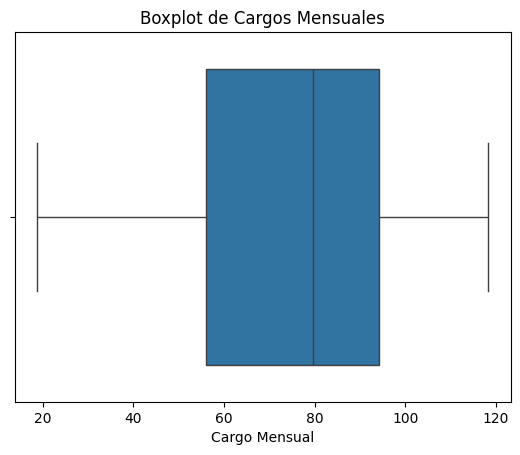

In [51]:
plt.figure()
sns.boxplot(x=clientes_churn_yes['account_Charges_Monthly'])

plt.title('Boxplot de Cargos Mensuales')
plt.xlabel('Cargo Mensual')

plt.show()

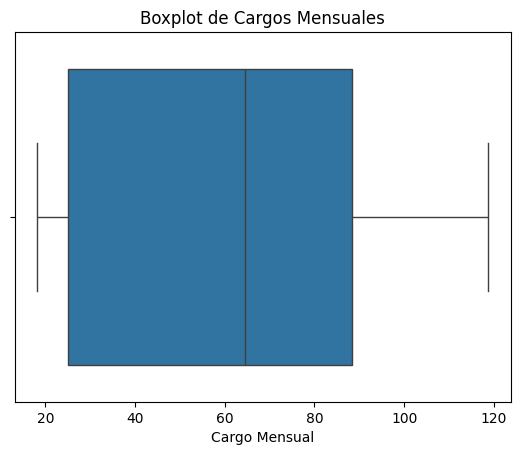

In [52]:
plt.figure()
sns.boxplot(x=clientes_churn_no['account_Charges_Monthly'])

plt.title('Boxplot de Cargos Mensuales')
plt.xlabel('Cargo Mensual')

plt.show()

Un 3 % (224) de los clientes de la base no tenian el dato referido a si seguian siendo clientes aun o ya no lo eran, fueron descartados para el analisis dado su baja proporción.
25% de los clientes que se dan de baja lo hacen en los primeros 2 meses y 50% lo hacen antes de los 10 meses.
88,55% de los clientes que se dieron de baja tenian contratos mensuales, 77% no tenían Tech Support, 57% utilizaban Electronic Check y 69% tenían Fiber Optic

Acciones comerciales posibles para enfrentar las principales causas de abandono encontradas en el análisis :

- Ofrecer descuento por migrar a contrato anual
- Beneficios exclusivos para contratos largos
- Programa de fidelización por permanencia
- Ofrecer TechSupport gratuito los primeros 6 meses
- Comunicación del valor del servicio
- Incentivo por pago mediante débito automático
- Contacto proactivo durante los primeros 2 meses (encuesta de satisfacción temprana)
     Si el problema son cargos altos :
      * Ofrecer downgrade plan personalizado (internet DSL o sin internet)
      * Descuento preventivo antes de que se vayan
